   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

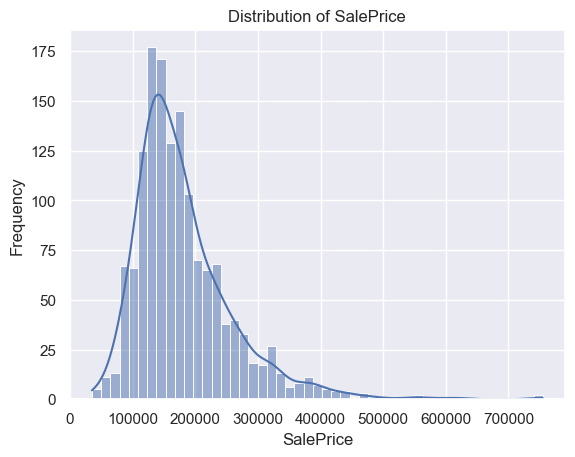

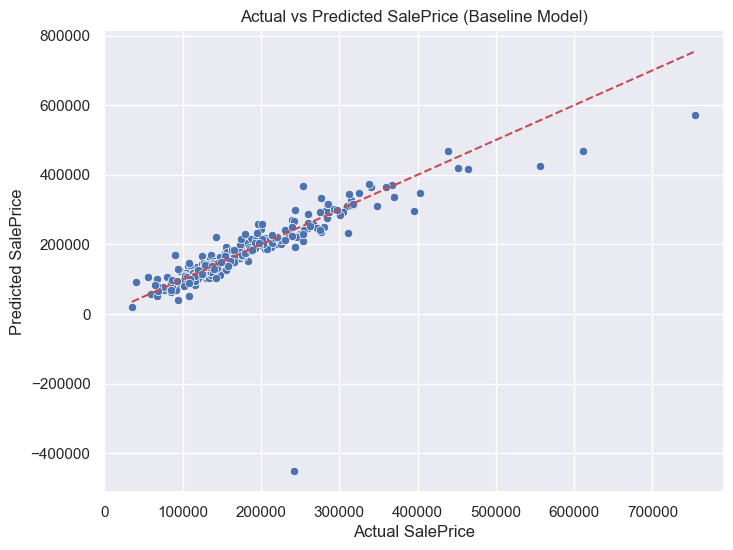

Post-Feature Engineering Mean Squared Error: 390892642.8657026
Post-Feature Engineering R2 Score: 0.9124299755085283
Post-Feature Engineering Mean Absolute Error: 14036.040848048979
Post-Feature Engineering Root Mean Squared Error: 19771.005105095253


C:\Users\LOQ\AppData\Roaming\Python\Python310\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [4, 7, 14, 18, 28] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


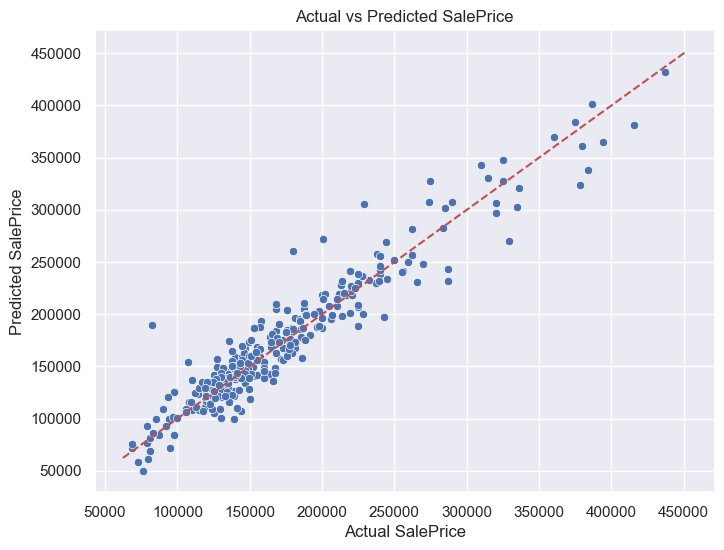

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Combine train and test data
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Keep only training data for this analysis
df = train_data.copy()
print(df.head())
print('Null counts:\n', df.isnull().sum())

#build a basic model without feature engineering to get a baseline score
from sklearn.model_selection import train_test_split
#using Linear Regression as a baseline model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Prepare data for modeling
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
#Handle missing values ,Encode categorical variables.
X = pd.get_dummies(X, drop_first=True)
X.fillna(X.mean(), inplace=True)
#handle missing values in target variable if any
y.fillna(y.mean(), inplace=True)
# Split data into training and validation sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train a simple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict and evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Baseline Mean Squared Error: {mse}')
#find r2 score
r2 = r2_score(y_test, y_pred)
print(f'Baseline R2 Score: {r2}')
#find mean absolute error
mae = mean_absolute_error(y_test, y_pred)
print(f'Baseline Mean Absolute Error: {mae}')
#rmse 
rmse = np.sqrt(mse)
print(f'Baseline Root Mean Squared Error: {rmse}')
#find the distribution of the target variable
sns.histplot(y, kde=True)
plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')
plt.show()
#plot the scatter plot of actual vs predicted values with a line of best fit to visualize the performance of the model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line of best fit
plt.title('Actual vs Predicted SalePrice (Baseline Model)')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.show()


#feature engineering 
# Create new features based on existing ones
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBathrooms'] = df['FullBath'] + (0.5 * df['HalfBath']) + df['BsmtFullBath'] + (0.5 * df['BsmtHalfBath'])
df['TotalPorchSF'] = df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch']
#dropping the features which are not useful for modeling
cols_to_drop = [col for col in ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature'] if col in df.columns]
df.drop(columns=cols_to_drop, inplace=True)

# apply one-hot encoding to categorical variables and column transformation to handle missing values
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Prepare data for modeling after feature engineering
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define transformers for numerical and categorical features
numerical_transformer = SimpleImputer(strategy='mean')
categorical_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

#since data is right skewed we will apply log transformation to the target variable and then handles outliers using iqr method
# Apply log transformation to the target variable
y_log = np.log1p(y)
# Handle outliers using IQR method
Q1 = y_log.quantile(0.25)
Q3 = y_log.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter both X and y to remove outliers
mask = (y_log >= lower_bound) & (y_log <= upper_bound)
X = X[mask]
y = y[mask]
y_log = y_log[mask]

# Split data into training and test sets after feature engineering
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Train a new Linear Regression model after feature engineering
model_fe = LinearRegression()
model_fe.fit(X_train_processed, y_train)

# Predict and evaluate the model after feature engineering
y_pred = model_fe.predict(X_test_processed)
mse = mean_squared_error(y_test, y_pred)
print(f'Post-Feature Engineering Mean Squared Error: {mse}')
r2 = r2_score(y_test, y_pred)
print(f'Post-Feature Engineering R2 Score: {r2}')
mae = mean_absolute_error(y_test, y_pred)
print(f'Post-Feature Engineering Mean Absolute Error: {mae}')
rmse = np.sqrt(mse)
print(f'Post-Feature Engineering Root Mean Squared Error: {rmse}')
#now plot the scatter plot of actual vs predicted values with a line of best fit to visualize the performance of the model
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # Line of best fit
plt.title('Actual vs Predicted SalePrice')
plt.xlabel('Actual SalePrice')  
plt.ylabel('Predicted SalePrice')
plt.show()




 

